# ВЫПУСКНАЯ КВАЛИФИКАЦИОННАЯ РАБОТА 

### Тема:
### *«Методы классификации текстовых документов на основе дообучения большой языковой модели»*

### EDA - Разведочный анализ данных

___

Произведем импорт необходимых библиотек.

In [1]:
import warnings

# Отключаем все предупреждения
warnings.filterwarnings("ignore")

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
import matplotlib.colors as mcolors
import numpy as np
from adjustText import adjust_text
from sentence_transformers import SentenceTransformer
import umap
import hdbscan
from sklearn.decomposition import PCA
import plotly.express as px
import json
from sklearn.feature_extraction.text import TfidfVectorizer
import spacy
from gensim import corpora
from gensim.models import LdaMulticore
import pyLDAvis
import pyLDAvis.gensim_models as gensim_lda


___
Вынесем в  отдельный блок функции для построения читаемых графиков

In [3]:
def plot_length_distribution(data, column='char_count', bins=150):
    'Гистограмма и ящик с усами '
    values = data[column].dropna()

    fig, (ax1, ax2) = plt.subplots(
        2, 1,
        figsize=(12, 7),
        gridspec_kw={'height_ratios': [4, 1]}
    )

    # Гистограмма
    ax1.hist(values, bins=bins, color='seagreen', edgecolor='white')
    ax1.set_ylabel('Количество')
    ax1.set_title(f'Распределение {column}')
    
    median_val = values.median()
    mean_val = values.mean()

    ax1.axvline(median_val, color='red', linestyle='--',
                label=f'Медиана: {median_val:.0f}')
    ax1.axvline(mean_val, color='orange', linestyle='--',
                label=f'Среднее: {mean_val:.0f}')
    ax1.legend()

    # Boxplot
    ax2.boxplot(
        values,
        vert=False,
        patch_artist=True,
        boxprops=dict(facecolor='seagreen', alpha=0.6),
        medianprops=dict(color='red', linewidth=2),
        flierprops=dict(marker='o', markerfacecolor='gray',
                        markersize=3, alpha=0.4)
    )
    ax2.set_xlabel(column)
    ax2.set_yticks([])

    plt.tight_layout()
    plt.show()

In [4]:
def plot_metric_by_label(df: pd.DataFrame, metric: str = None, ascending: bool = True):
    """
    Строит красивый горизонтальный барчарт по блокам (label).
    """

    # Если метрика не указана — считаем количество писем в каждом блоке
    if metric is None:
        data = df['label'].value_counts().sort_values(
            ascending=ascending).to_frame()
        metric = 'count'
    # Иначе — считаем среднее значение метрики по каждому блоку
    else:
        data = df.groupby('label')[[metric]].mean(
        ).sort_values(metric, ascending=ascending)

    fig, ax = plt.subplots(figsize=(12, 14))

    # Градиент цвета 
    colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(data)))
    bars = ax.barh(data.index, data[metric], color=colors,
                   edgecolor='white', linewidth=0.5, height=0.7)

    # числовое значение справа от каждого бара
    for bar, val in zip(bars, data[metric]):
        ax.text(
            val + data[metric].max() * 0.01,        
            bar.get_y() + bar.get_height() / 2,     # по центру бара по высоте
            f'{val:.0f}' if metric == 'count' else f'{val:.3f}',  # формат числа
            va='center', ha='left', fontsize=8, color='#333333'
        )

    # Вертикальная линия медианы 
    median_val = data[metric].median()
    ax.axvline(median_val, color='steelblue',
               linestyle='--', linewidth=1.2, alpha=0.7)
    ax.text(
        median_val + data[metric].max() * 0.005, -0.8,
        f'медиана\n{median_val:.0f}' if metric == 'count' else f'медиана\n{median_val:.3f}',
        fontsize=8, color='steelblue', va='top'
    )

    # Заголовок и подпись оси зависят от того что строим
    title = 'Распределение блоков по количеству писем' if metric == 'count' else f'{metric} по блокам'
    xlabel = 'Количество писем' if metric == 'count' else f'{metric} (среднее)'
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel(xlabel, fontsize=11)

    # место справа чтобы подписи не обрезались
    ax.set_xlim(0, data[metric].max() * 1.15)

    # убираем лишние рамки 
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)

    ax.tick_params(axis='y', labelsize=9)

    # Сетка на задний план
    ax.xaxis.grid(True, linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)

    plt.tight_layout()
    plt.savefig(f'{metric}_by_label.png', dpi=150, bbox_inches='tight')
    plt.show()

In [5]:
def plot_scatter_two_metrics(df: pd.DataFrame,
                             metric_x: str,
                             metric_y: str):
    """
    Строит scatter plot соотношения двух метрик по блокам (label).
    """

    agg = df.groupby('label')[[metric_x, metric_y]].mean().reset_index()

    score = (agg[metric_x] - agg[metric_x].min()) / \
        (agg[metric_x].max() - agg[metric_x].min())

    fig, ax = plt.subplots(figsize=(16, 10))

    ax.scatter(agg[metric_x], agg[metric_y],
               c=score, cmap='RdYlGn',
               s=120, edgecolors='white', linewidth=0.8, zorder=3)

    # Собираем подписи отдельно — adjust_text сам их разведёт
    texts = []
    for _, row in agg.iterrows():
        texts.append(ax.text(
            row[metric_x], row[metric_y],
            row['label'],
            fontsize=7.5, color='#333333'
        ))

    # Разводим подписи — arrowprops рисует стрелку от подписи к точке
    adjust_text(
        texts,
        ax=ax,
        arrowprops=dict(arrowstyle='-', color='gray', lw=0.6),
        expand=(1.5, 1.8),       # насколько сильно разводить
        force_text=(0.5, 0.8),   # сила отталкивания между подписями
    )

    # Линии медиан
    x_med = agg[metric_x].median()
    y_med = agg[metric_y].median()
    ax.axvline(x_med, color='steelblue', linestyle='--',
               linewidth=1, alpha=0.6, label=f'медиана {metric_x}')
    ax.axhline(y_med, color='tomato',    linestyle='--',
               linewidth=1, alpha=0.6, label=f'медиана {metric_y}')

    # Подписи квадрантов
    x_min, x_max = agg[metric_x].min(), agg[metric_x].max()
    y_min, y_max = agg[metric_y].min(), agg[metric_y].max()
    quad_style = dict(fontsize=8, alpha=0.4, fontstyle='italic')
    ax.text(x_med + (x_max - x_med) * 0.6, y_max,
            'длинные и разнообразные',  ha='center', color='green',  **quad_style)
    ax.text(x_min + (x_med - x_min) * 0.3, y_max,
            'короткие и разнообразные', ha='center', color='olive',  **quad_style)
    ax.text(x_med + (x_max - x_med) * 0.6, y_min + 0.005,
            'длинные и шаблонные',      ha='center', color='tomato', **quad_style)
    ax.text(x_min + (x_med - x_min) * 0.3, y_min + 0.005,
            'короткие и шаблонные',     ha='center', color='gray',   **quad_style)

    sm = plt.cm.ScalarMappable(cmap='RdYlGn', norm=plt.Normalize(0, 1))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label(f'{metric_x} (нормализовано)', fontsize=9)
    cbar.set_ticks([0, 0.5, 1])
    cbar.set_ticklabels(['мало', 'средне', 'много'])

    ax.set_xlabel(metric_x, fontsize=11)
    ax.set_ylabel(metric_y, fontsize=11)
    ax.set_title(f'{metric_x} vs {metric_y} по блокам',
                 fontsize=13, fontweight='bold', pad=15)
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.xaxis.grid(True, linestyle='--', alpha=0.4)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)
    ax.set_axisbelow(True)

    plt.tight_layout()
    plt.savefig(f'scatter_{metric_x}_{metric_y}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

___
Блок функций которые я использовал для очистки текста внутри писем.

In [6]:
# удаляем подряд идущие одинаковые слова
def remove_repeated_words(text: str):
    # пример: "работа работа работа" → "работа"
    return re.sub(r'\b(\w+)(\s+\1\b)+', r'\1', text, flags=re.IGNORECASE)

In [7]:
# удаляем длинные повторяющиеся куски (даже если это часть одного огромного предложения)
def remove_repeated_sequences(text: str, min_words=5, max_words=30):
    # это нужно когда повторяется фраза по 50-100 раз подряд
    words = text.split()
    i = 0
    result = []

    while i < len(words):
        found_repeat = False

        # проверяем куски разной длины
        for size in range(max_words, min_words - 1, -1):

            # если не хватает слов — просто пропускаем
            if i + size * 2 > len(words):
                continue

            phrase1 = words[i:i+size]
            phrase2 = words[i+size:i+size*2]

            # если нашли повтор
            if phrase1 == phrase2:
                result.extend(phrase1)

                # пропускаем ВСЕ одинаковые повторы подряд
                j = i + size
                while j + size <= len(words) and words[j:j+size] == phrase1:
                    j += size

                i = j
                found_repeat = True
                break

        if not found_repeat:
            result.append(words[i])
            i += 1

    return " ".join(result)

In [8]:
# убираем повторяющиеся строки (часто бывает в логах или выгрузках)
def remove_duplicate_lines(text: str):
    seen = set()
    cleaned_lines = []

    for line in text.split("\n"):
        normalized = line.strip().lower()
        if normalized and normalized not in seen:
            cleaned_lines.append(line.strip())
            seen.add(normalized)

    return "\n".join(cleaned_lines)

In [9]:
#  удаляем одинаковые предложения
def remove_duplicate_sentences(text: str):
    # делим по . ! ?
    sentences = re.split(r'(?<=[.!?])\s+', text.strip())
    seen = set()
    result = []

    for s in sentences:
        s_clean = s.strip()
        key = s_clean.lower()
        if key and key not in seen:
            seen.add(key)
            result.append(s_clean)

    return " ".join(result)

In [10]:
#  чистим повторы через запятую
def remove_repeated_comma_phrases(text: str):
    pattern = r'(.{20,200}?)(?:,\s*\1){2,}'
    return re.sub(pattern, r'\1', text, flags=re.IGNORECASE)

In [11]:
# нормализация пробелов
def normalize_text(text: str):
    text = re.sub(r'[ \t]+', ' ', text)
    text = re.sub(r'\n\s*\n+', '\n\n', text)
    return text.strip()


In [12]:
# Проходка по всем функциям
def clean_text(text: str):
    if not isinstance(text, str):
        return text

    # сначала убираем очевидный спам
    text = remove_repeated_words(text)

    # потом длинные повторяющиеся куски
    text = remove_repeated_sequences(text)

    # чистим повторяющиеся строки
    text = remove_duplicate_lines(text)

    # убираем дубли предложений
    text = remove_duplicate_sentences(text)

    # убираем повтор через запятую
    text = remove_repeated_comma_phrases(text)

    # финальная зачистка пробелов
    text = normalize_text(text)

    return text

___
### Знакомство с данными
Импортируем данные и произведем первичный анализ.

In [13]:
data = pd.read_json("/Users/kvt/Documents/VKR/code/Data/data.json")
data.head()

,idx,text,label
0,10026,[PERSON]\n\nУважаемый [PERSON]!\n\n[ORGANIZATI...,Блок директора по проектированию
1,1005,[ORGANIZATION] инжиниринг общество с ограничен...,Блок деректора по газу
2,1010,[ORGANIZATION] ИНВЕСТ Общество с ограниченной ...,Блок заместителя генерального директора по без...
3,10108,"[ORGANIZATION] ОГРН: [ID], ИНН/КПП: [ID] РФ, [...",Блок технического директора
4,1013,[ORGANIZATION] филиал [OBJECT] имени [PERSON] ...,Блок технического директора


___
Наши данные состоят из 3 столбцов:

- индекс письма,

- тект письма,

- целевая переменная.

Данные в тексте письма обезличены.
___

Оценим общую информацию

In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1774 entries, 0 to 1773
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   idx     1774 non-null   object
 1   text    1774 non-null   object
 2   label   1774 non-null   object
dtypes: object(3)
memory usage: 41.7+ KB


In [15]:
data.describe()

,idx,text,label
count,1774,1774,1774
unique,1774,1769,36
top,17052P,[ORGANIZATION] Юридический адрес: [LOCATION] П...,Блок технического директора
freq,1,2,249


В данных у нас 1774 письма, и нет пропусков.

Всего существует 36 блоков.
___
Рассмотрим распределение по блокам

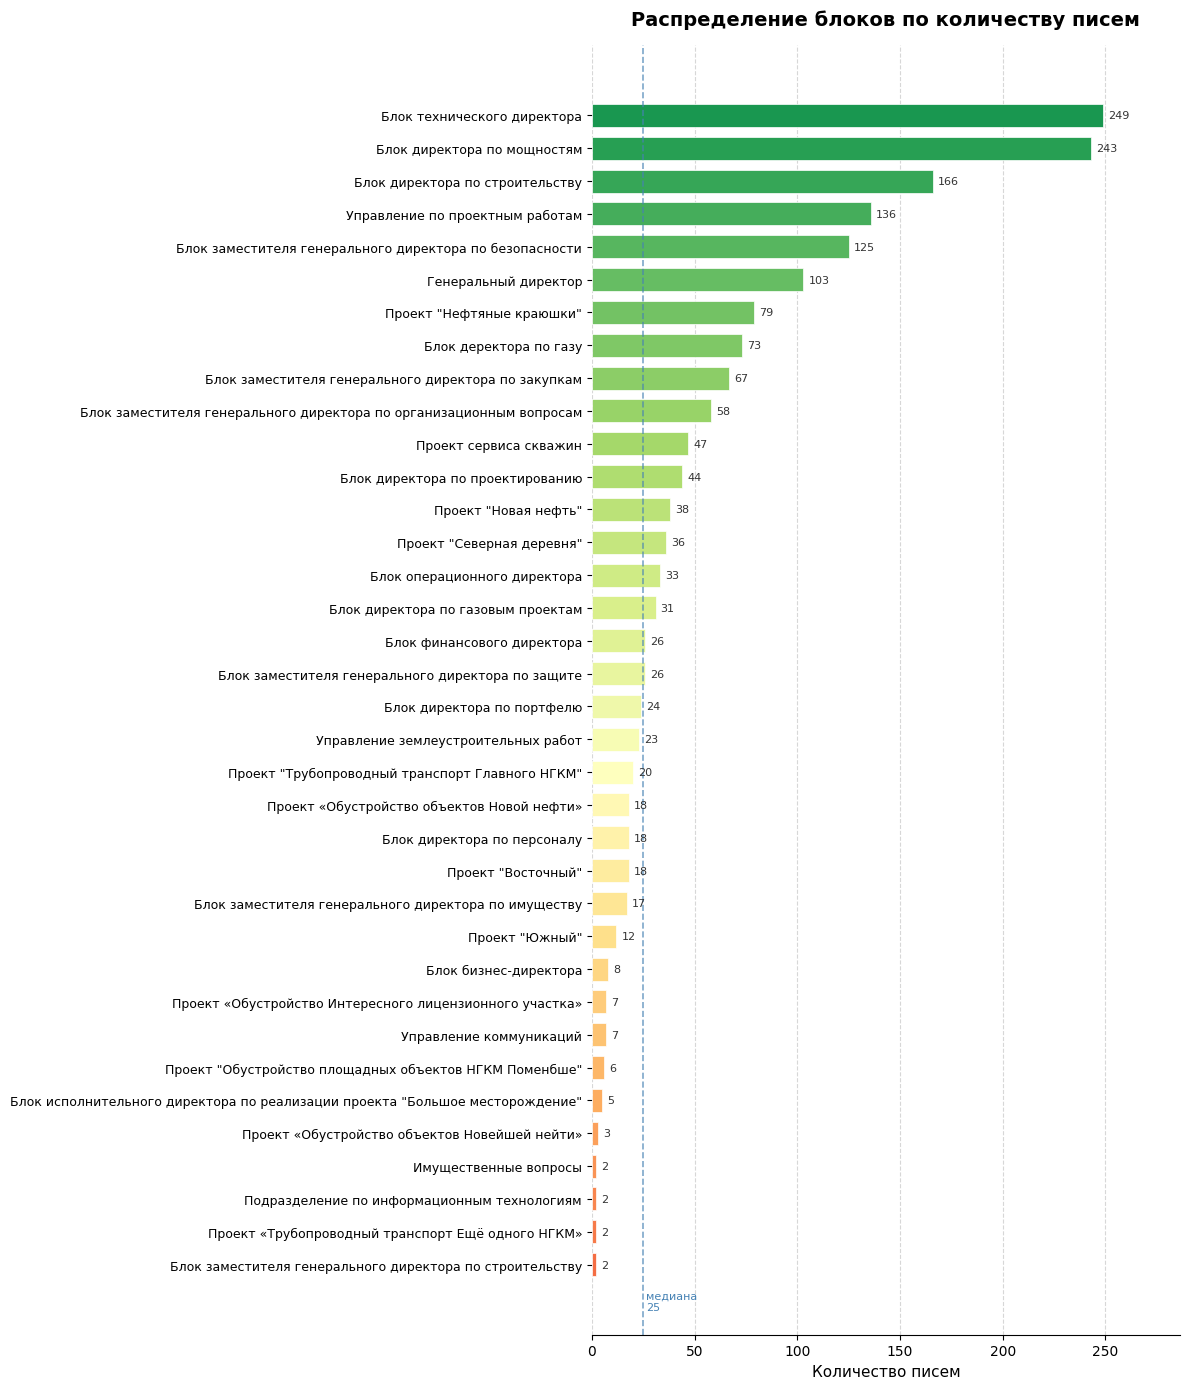

In [16]:
# распределение по количеству писем
plot_metric_by_label(data)

In [17]:
counts = data["label"].value_counts()
print("Блоков с < 10 примеров:", (counts < 10).sum())
print("Блоков с < 20 примеров:", (counts < 20).sum())

Блоков с < 10 примеров: 10
Блоков с < 20 примеров: 15


Малое количество примеров в блоке может вызвать проблемы в дальнейшем обучении. 

Необходимо будет найти подход для синтеза данных в этих блоках.
___

Попробуем поискать дубликаты в данных:

In [18]:
duplicates_count = data.duplicated().sum()
print(f"Количество строк-дубликатов: {duplicates_count}")

Количество строк-дубликатов: 0


___
### Поиск закономерностей и аномалий в простых текстовых параметрах
Теперь изучим параметры писем и сравним их по блокам.

Для этого оценим такие параметры как: 
- количество символов,
- общее количество слов в письме,
- количество предложений,
- количество уникальных слов в письме.


In [19]:
def basic_text_metrics(text: str) -> dict:
    words = re.findall(r'\b\w+\b', text.lower())
    sentences = [s.strip() for s in re.split(r'[.!?]+', text) if s.strip()]

    return {
        'char_count':     len(text),
        'word_count':     len(words),
        'sentence_count': len(sentences),
        'unique_word_count': len(set(words)),
    }

In [20]:
metrics_data = data['text'].apply(lambda t: pd.Series(basic_text_metrics(t)))

data  = pd.concat([data, metrics_data], axis=1)

Выведем простые параметры и поищем закономерности.

In [21]:
data[['char_count', 'word_count', 'sentence_count',
     'unique_word_count', 'text', 'idx']].sort_values('unique_word_count').head(20)

,char_count,word_count,sentence_count,unique_word_count,text,idx
878,46565,3105,1,5,[ORGANIZATION] [LOCATION] [CONTACT] [DATE_TIME...,5831
836,49,6,1,5,МНН / КПП [ID] / [ID] Организация: [ORGANIZATION],5749
252,46982,5217,1,6,[ORGANIZATION] [ORGANIZATION] [PERSON] [PERSON...,14272
733,179,13,1,6,[ORGANIZATION] [ORGANIZATION] [ORGANIZATION] [...,5587
1637,261,19,1,6,[ORGANIZATION] [LOCATION] [CONTACT] [DATE_TIME...,6925
1191,118,10,1,6,[ORGANIZATION] [ORGANIZATION] [LOCATION] [CONT...,6917
33,246,18,1,6,[ORGANIZATION] [LOCATION] [CONTACT] [DATE_TIME...,1139
1362,92,8,1,7,[ORGANIZATION] [OBJECT] [LOCATION] [CONTACT] [...,6053
1215,68101,3786,1,7,[ORGANIZATION] [LOCATION] [CONTACT]; [ID] [DAT...,7012
743,44872,4983,1,7,[ORGANIZATION] [LOCATION] [CONTACT] [ORGANIZAT...,5602


Вижу, что в данных присутствуют такие письма, где несколько тысяч слов, при этом уникальных слов 5-10, это явно похоже на аномалию.
Выделим письма где уникальных слов меньше 30, а слов больше 200.

In [22]:
mask = (data['unique_word_count'] < 50) & (data['word_count'] > 200)
print(f"Обнаружено {data[mask]['idx'].count()} аномальных писем.")
data = data.drop(data[mask].index)
print("Письма удалены")

Обнаружено 19 аномальных писем.
Письма удалены


___
Посмортрим распределение по количеству символов.

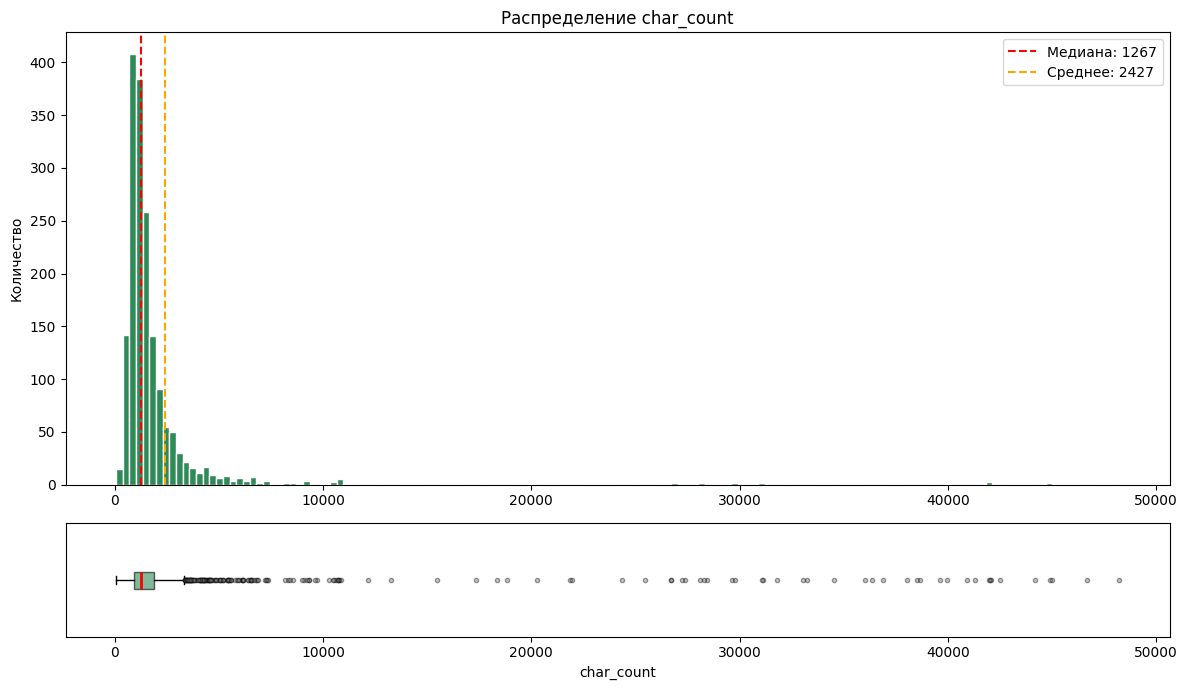

In [23]:
plot_length_distribution(data, 'char_count')

Посмотрим самое длинное письмо, является ли оно аномальным по содержанию. 

In [24]:
data['char_count'].describe()

count     1755.000000
mean      2427.071795
std       5217.083863
min         49.000000
25%        919.500000
50%       1267.000000
75%       1888.500000
max      48241.000000
Name: char_count, dtype: float64

In [25]:
print(data[data['char_count'] == 48241]['text'].iloc[0])

[ID], [PERSON], [ORGANIZATION] [PERSON] Коммерческое предложение Уважаемый [PERSON]! Мы проявляем интерес к Вашему предложению о сотрудничестве в области энергетики. В [DATE_TIME] было подписано соглашение о сотрудничестве с [ORGANIZATION] от [DATE_TIME] No [DOCUMENT_NUMBER] О порядке обсуждения по окончании проверки захвата объекта труда. Некоторые нюансы [ORGANIZATION] в частности в конце текущего года [YEAR], некоторые - в начале следующего года [YEAR]. В частности, с [DATE_TIME] на объекте обсуждение вопросов по техническому состоянию системы безопасности, в частности по вопросам ЕНСОТ. На основании этого, с целью обеспечения безопасности объекта труда, мы предлагаем Вам рассмотреть возможность создания системы безопасности (ЕНСОТ). На основании этого, с целью обеспечения безопасности объекта труда, мы предлагаем Вам рассмотреть возможность создания системы безопасности (ЕНСОТ). В связи с этим, мы предлагаем Вам рассмотреть возможность создания системы безопасности (ЕНСОТ). В связи

Данное письмо содержит много копий одного предложения и явно  является аномалией. 

Так же письма  могут содержать дубликаты повторяющихся подряд, фраз слов, строк. 
___
Пройдемся по письмам и удалим  все лишнее, для этого используются функции из блока выше.

In [26]:
# удаляем дубликаты(строк, фпраз, предложений) в тексте
data['text'] = data['text'].apply(clean_text)

#Удаляем базовые параметры и пересчитываем их заново
data = data.drop(columns=['char_count', 'word_count', 'sentence_count',
     'unique_word_count'])

metrics_data = data['text'].apply(lambda x: pd.Series(basic_text_metrics(x)))

data  = pd.concat([data, metrics_data], axis=1)

После удаления построим наш график заново

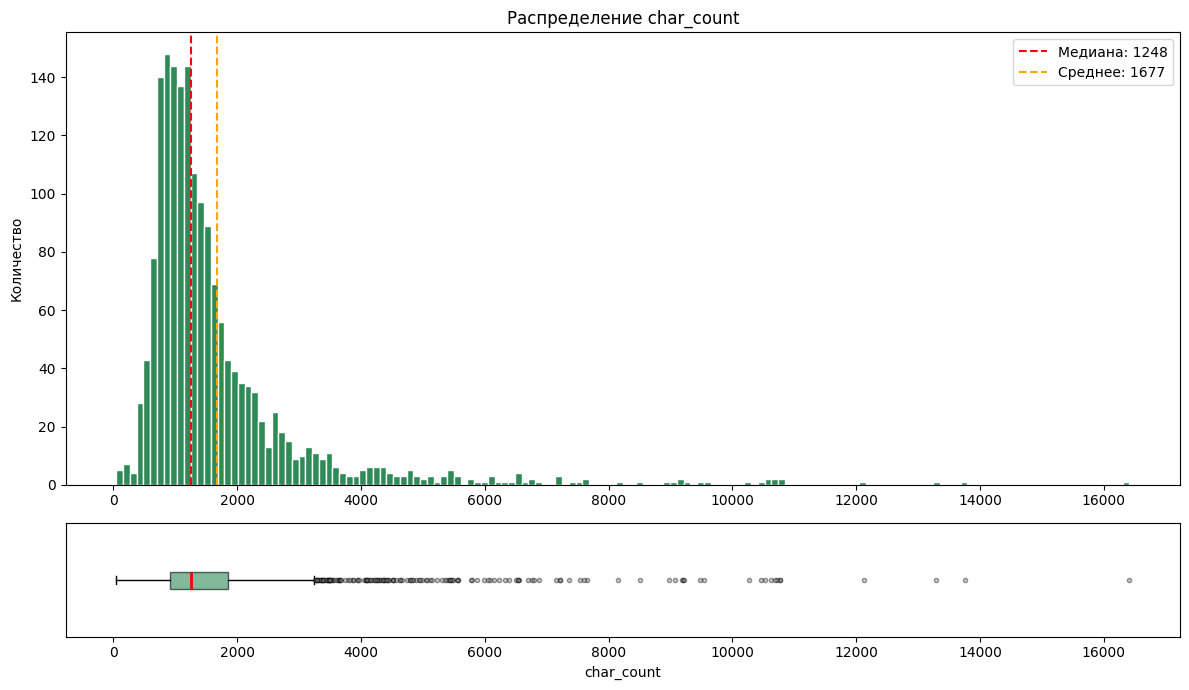

In [27]:
plot_length_distribution(data, 'char_count')

Количество выбросов явно сократилось.

In [28]:
data['char_count'].describe()

count     1755.00000
mean      1677.11453
std       1477.85625
min         49.00000
25%        909.00000
50%       1248.00000
75%       1848.00000
max      16411.00000
Name: char_count, dtype: float64

Посмотрим на предложение  содерджащее более всего символов.

In [29]:
print(data[data['char_count'] == 16411]['text'].iloc[0])

[ORGANIZATION] на объекте по ш [NUMBER] Уважаемый [PERSON]! В соответствии с заданием на проектирование объекта [PROJECT_NAME]. Этапы 1, 2, 3 (п. 20.9), а также выполнение технического задания на разработку разделов Геотехнический мониторинг и Термостабильная грунтовая вода (п. 3.4-3.5) в рамках разработки раздела проектной документации Геотехнический мониторинг требуется создание автоматизированной системы геотехнического мониторинга проектных объектов. Наравнеем в Ваш адрес предложение по организации комплексной системы мониторинга (КСМ) площадных и линейных объектов: No Индекс системы КСМ Контролируемые параметры Обеспечение для системы 1 Автоматизированная система термометрического контроля рабочих особых термометрических чувствительных элементов Распределение и установка температурных датчиков контроля и измерения СН 25.13330.2020 Обеспечение контроля и измерения температуры рабочих особых термометров, п. 15.3 2 Автоматизированная система контроля протяженного контрольного кабеля 

Данное письмо выглядит как длинный перечень но уже не выглядит как аномалия, с повторяющимися фразами или предложениями.

___ 
Построим аналогичную диаграмму по количеству слов.

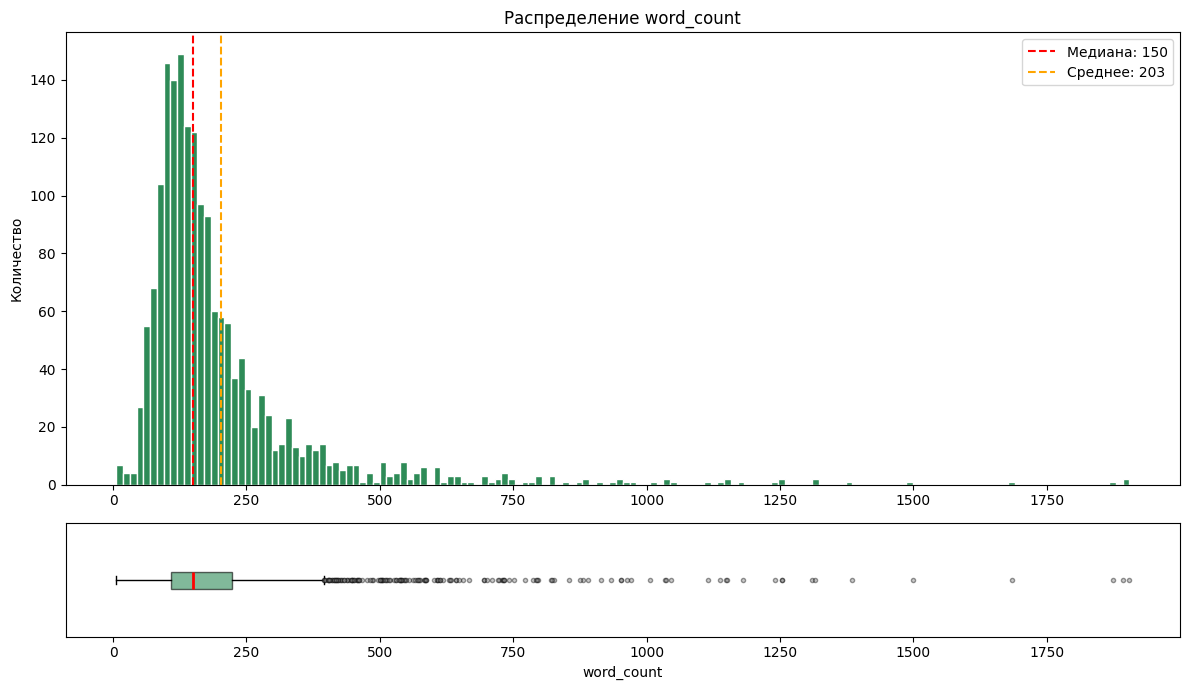

In [30]:
plot_length_distribution(data, 'word_count')

Для количества уникальных слов.

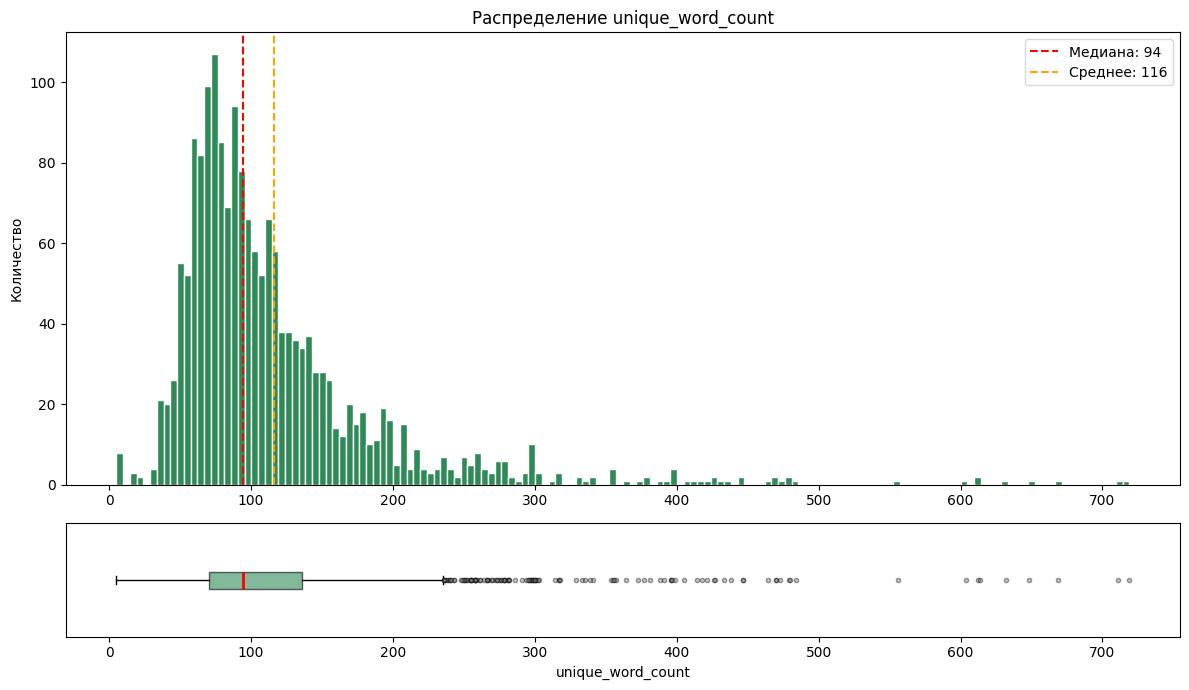

In [31]:
plot_length_distribution(data, 'unique_word_count')

Распределения в целом похожи на распределение количества символов.

In [32]:
data['unique_word_count'].describe()

count    1755.000000
mean      116.486040
std        78.221962
min         5.000000
25%        70.000000
50%        94.000000
75%       136.000000
max       719.000000
Name: unique_word_count, dtype: float64

In [33]:
print(data[data['unique_word_count'] == 719]['text'].iloc[0])

[ORGANIZATION] добыча [LOCATION] Общество с ограниченной ответственностью [ORGANIZATION] добыча [LOCATION] (ООО [ORGANIZATION] добыча [LOCATION]) [LOCATION] г. [CITY] [REGION], Российская Федерация, [ZIP_CODE] тел.: [CONTACT], факс: [CONTACT] e-mail: [CONTACT] www.[ORGANIZATION].ru [ID] [DATE_TIME] No [DOCUMENT_NUMBER] на [DATE_TIME] на нарушении пропускного и внутриобъектового режимов на [OBJECT] Уважаемый [PERSON]! [DATE_TIME] на КПП [NUMBER] [OBJECT] при заезде вахтового персонала был выявлен работник [ORGANIZATION] [PERSON], состоящий в должности помощник бурильщика. При осмотре личных вещей были обнаружены пластиковые банки в виде шайб с жевательным табаком [PRODUCT] в количестве двух штук. В соответствии со Стандартом [ORGANIZATION] Пропускной и внутриобъектовый режимы [STANDARD_NUMBER] провоз данного вещества на объекты [OBJECT] запрещен. Прошу Вас поручить проведение претензионной работы по данному факту, о результатах которой и принятых мерах сообщить в СКЗ [ORGANIZATION]. Доп

Рассмотрим средние показатели по блокам.

In [34]:
data.groupby('label')[['char_count', 'word_count', 'sentence_count', 'unique_word_count'
                       ]].mean().sort_values('unique_word_count', ascending=False)

,char_count,word_count,sentence_count,unique_word_count
label,,,,
Имущественные вопросы,7073.000000,846.000000,60.500000,330.500000
Проект «Трубопроводный транспорт Ещё одного НГКМ»,1947.000000,238.500000,12.000000,158.000000
"Блок исполнительного директора по реализации проекта ""Большое месторождение""",2002.200000,239.600000,14.000000,148.800000
Блок заместителя генерального директора по безопасности,2399.609756,282.796748,15.593496,148.081301
Подразделение по информационным технологиям,1633.500000,192.000000,11.000000,140.000000
Блок финансового директора,2480.400000,298.120000,19.360000,139.560000
"Проект ""Северная деревня""",1907.833333,228.833333,15.527778,136.527778
Блок технического директора,1928.829268,236.995935,16.268293,133.556911
Блок заместителя генерального директора по имуществу,1973.437500,241.875000,15.750000,132.937500


Выделяется блок по имущественным вопросам, как по общему количеству слов, так и по уникальному количеству слов.

___
### Поиск закономерностей и аномалий в других текстовых параметрах
Перейдем к оценке более сложных параметров:
- TTR — Type-Token Ratio - отношение уникальных слов к общему числу слов. Чем выше данный параметр, тем лексически разнообразней составлено письмо что может указывать на большую специфику, например технические или юридические термины.
- RTTR — Root Type-Token Ratio -  так же харрактеризует отношение уникальных слов к общему числу слов, но за счет деления на корень квадратный из общего количества слов компенсирует зависимость от длины всего текста, что позволяет сравнивать между собой короткие и длинные письма.
- Средняя длинна слова - так же может позволить отделить письма с проффессиональной терминологией от писем общего харрактера.
- Среднее количество слов в предложении - сложносочиненные предложения могут отражать бюрократические или юридические письма, в то же время более простые могут намекать на операционную деятельность.
- Доля длинных слов более 8 символов - чем выше данный показатель, тем как правило больше используется терминологии.
- Доля уникальных слов hapax

In [35]:
def advanced_text_metrics(text: str):
    'Функция для расчета параметров'
    words = re.findall(r'\b\w+\b', text.lower())
    sentences = [s.strip() for s in re.split(r'[.!?]+', text) if s.strip()]
    word_count = len(words)

    if word_count == 0:
        return {
            'ttr': 0,
            'rttr': 0,
            'avg_word_length': 0,
            'avg_sentence_length': 0,
            'long_word_ratio': 0,
            'hapax_ratio': 0,
        }

    unique_words = set(words)
    word_freq = Counter(words)

    return {
        # Лексическое разнообразие
        'ttr':  len(unique_words) / word_count,
        'rttr': len(unique_words) / (word_count ** 0.5),

        # Средние длины
        'avg_word_length': sum(len(w) for w in words) / word_count,
        'avg_sentence_length': word_count / len(sentences) if sentences else 0,

        # Сложность
        'long_word_ratio': sum(1 for w in words if len(w) > 8) / word_count,
        'hapax_ratio': sum(1 for w, c in word_freq.items() if c == 1) / word_count,
    }

In [36]:
advanced_df = data['text'].apply(advanced_text_metrics).apply(pd.Series)
data  = pd.concat([data, advanced_df], axis=1)

___
Рассмотрим 'ttr'  по блокам.

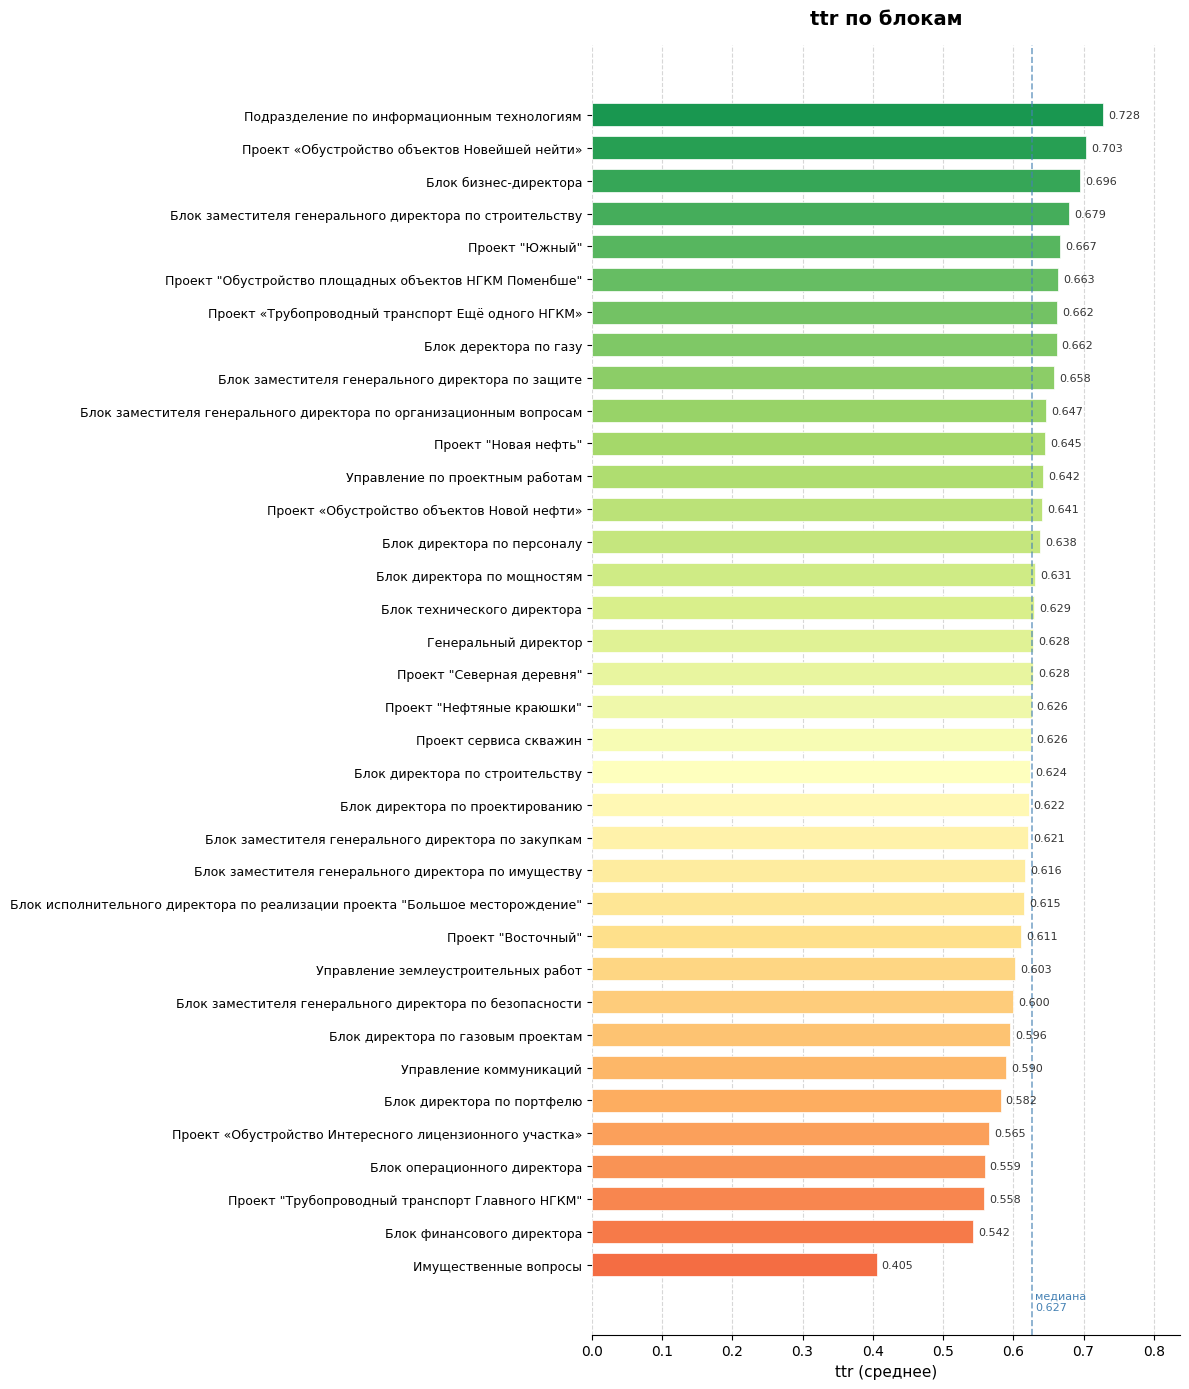

In [37]:
plot_metric_by_label(data, 'ttr')                 # лексическое разнообразие

Имущественные вопросы , самый низкий ttr. 

При этом письма имеют большой обьем слов.

 Низкий TTR при большом объёме может говорить о шаблонных юридических формулировках, которые повторяются.

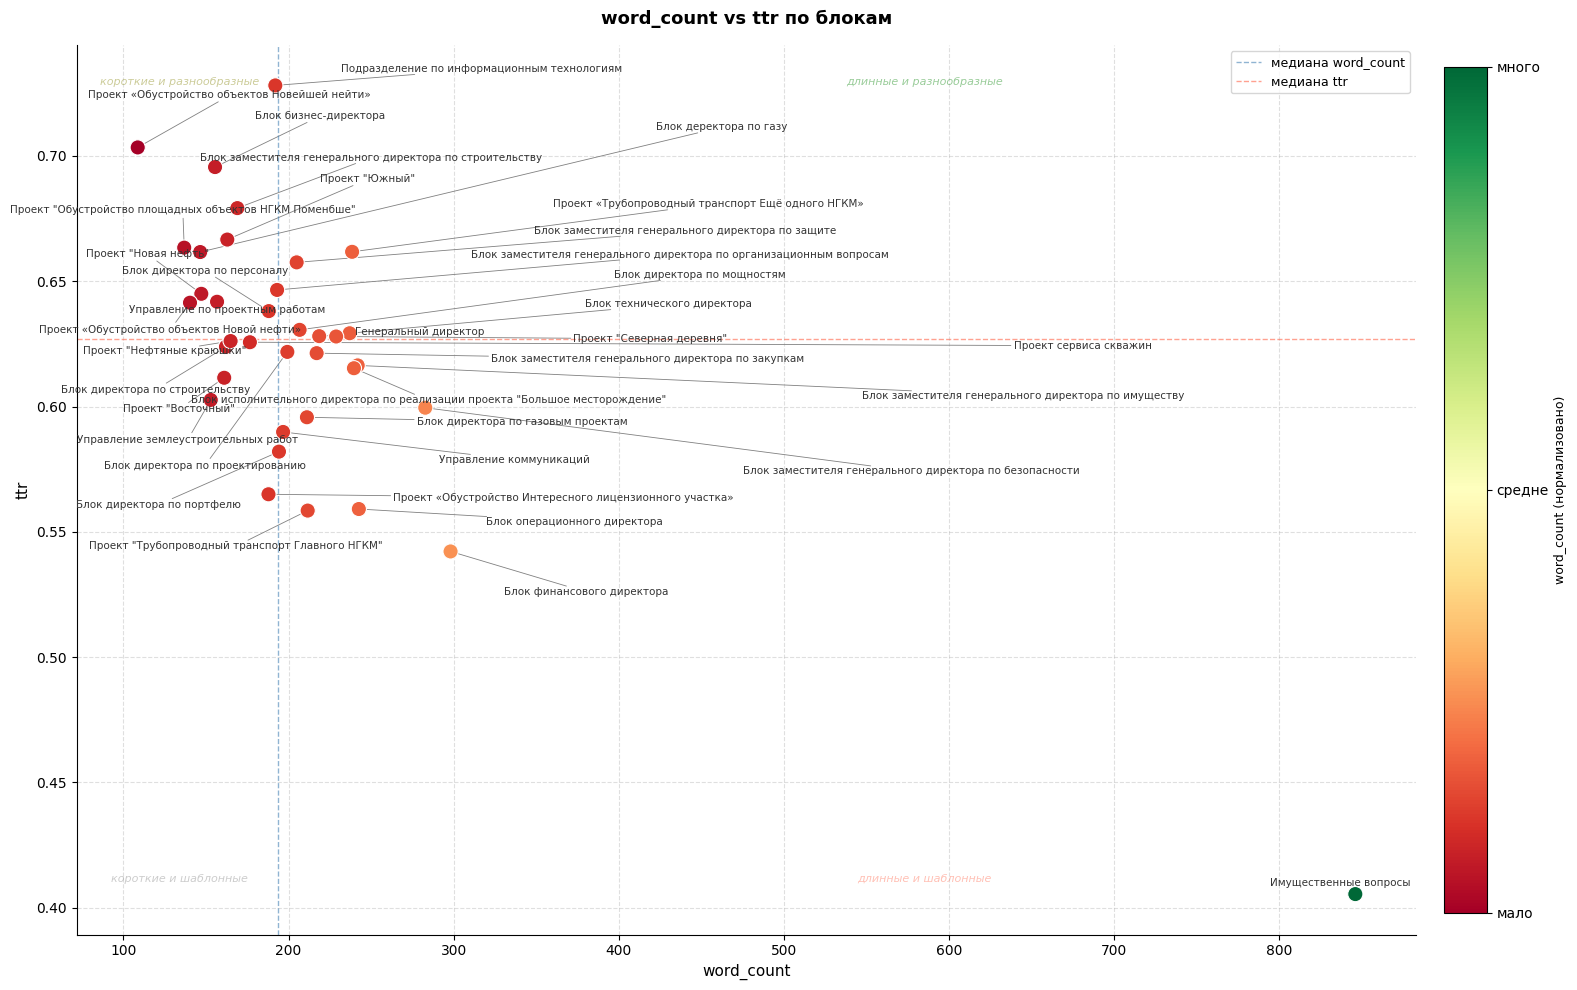

In [38]:
plot_scatter_two_metrics(data, 'word_count', 'ttr')

Блок Имущественные вопросы состоит из длинных шаблонных фраз и перечней и легко отделим от остальных блоков.
___
rttr

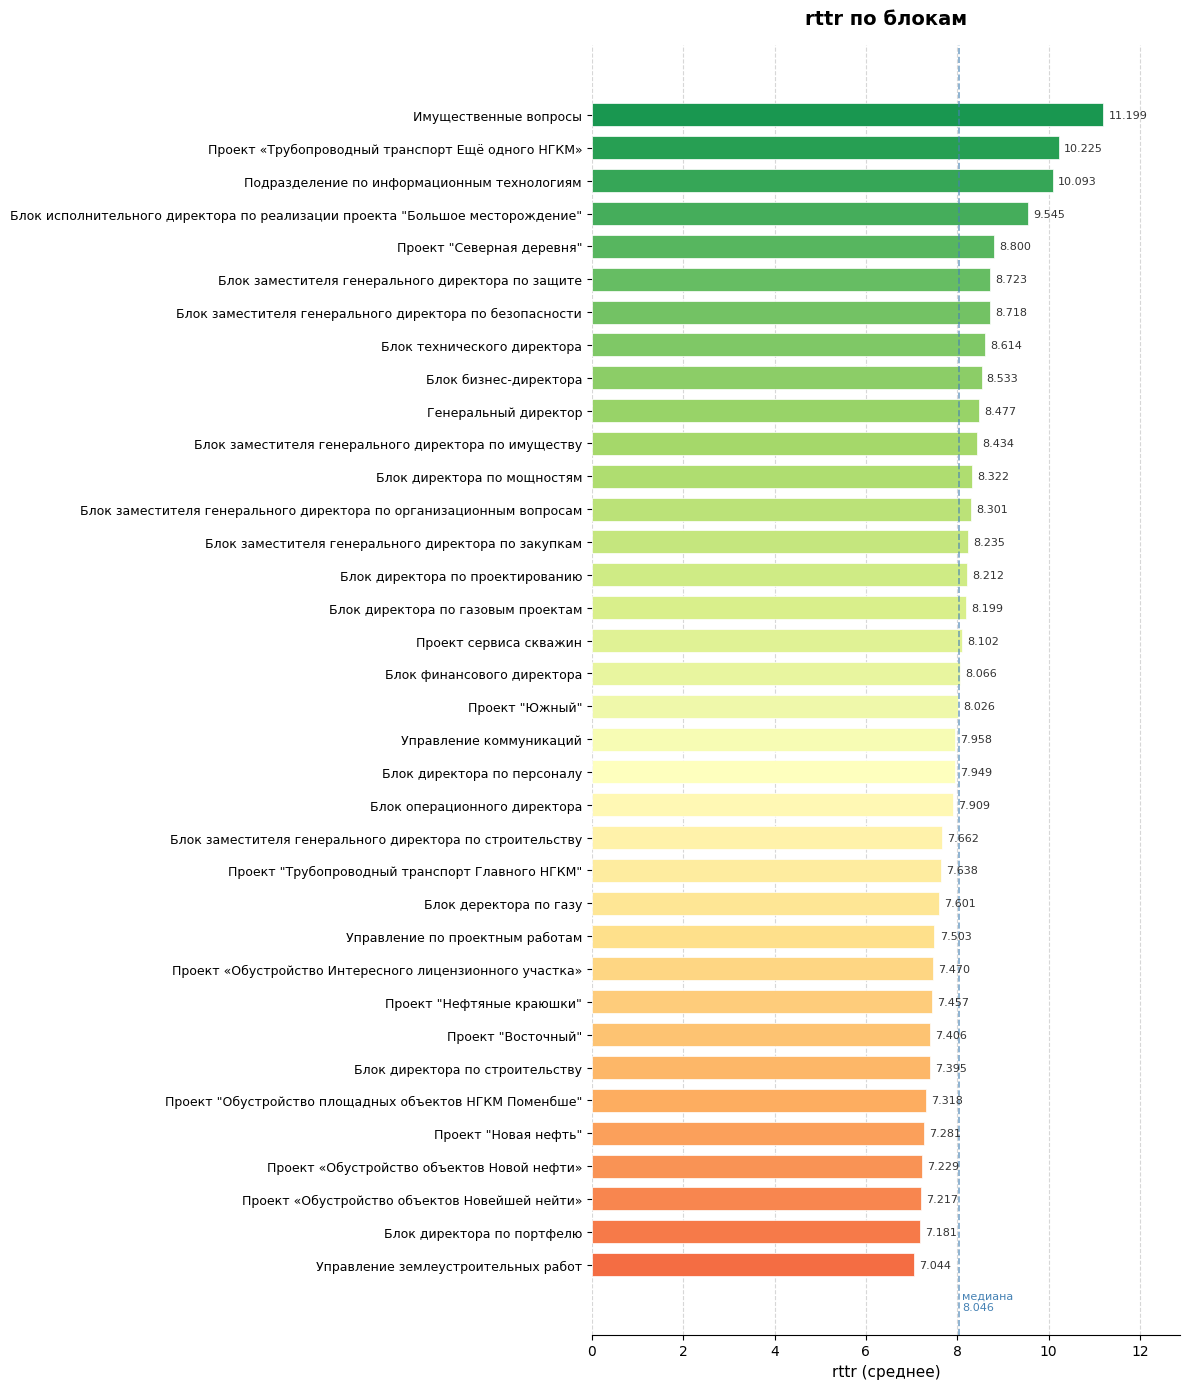

In [39]:
plot_metric_by_label(data, 'rttr')                 # лексическое разнообразие без учета длинны предложений


Здесь  можно заметить что Блоки с названиями начинающимися на  "Блок" в большинстве своем более лексически разнообразны в отличие от Блоков с названиями "Проект"

Получается,  что Блок Имущественные вопросы имеет длинные разнообразные по словам формулировки, но при этом содержит большое количество повторов.
___
Средняя длина слов

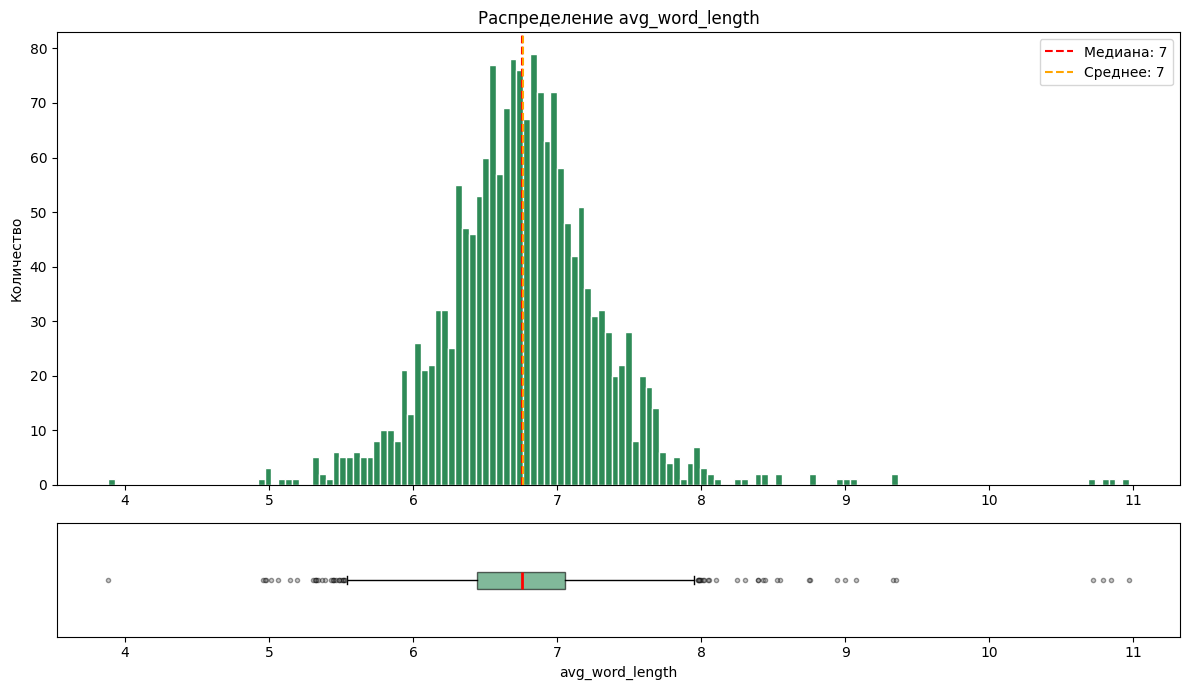

In [40]:
plot_length_distribution(data, 'avg_word_length')

Распределение похоже на нормальные, посмотрим  крайние значения что бы оценить их на аномальность.

In [41]:
data['avg_word_length'].describe()


count    1755.000000
mean        6.763469
std         0.560535
min         3.882260
25%         6.444444
50%         6.755102
75%         7.054952
max        10.968610
Name: avg_word_length, dtype: float64

In [42]:
print(data[data['avg_word_length'] < 4]['text'].iloc[0])

[ORGANIZATION] [LOCATION] ОГРН [ID] ИНН [ID] Тел/факс: [CONTACT] E-mail: [CONTACT] [DATE_TIME] г. No [DOCUMENT_NUMBER] На No от [YEAR] г. О предоставлении подтверждающих документов для индексации договорных расценок Уважаемый [PERSON]! [ORGANIZATION] свидетельствует Вам свое почтение и благодарит за предоставленную возможность реализации совместных с [ORGANIZATION] проектов. В ответ на Ваше письмо No [DOCUMENT_NUMBER] от [DATE_TIME] согласно запросу, направляем документацию, подтверждающую необходимость и обоснованность индексации договорных расценок в рамках действующего договора No [DOCUMENT_NUMBER] от [DATE_TIME] на выполнение работ по освоению скважин методами свабирования и компрессирования при ТКРС. Пакет документации, содержащий в том числе калькуляцию расходов на ФОТ, CaCl и ГСМ, в полной мере отражает факт увеличения затрат в рамках реализации вышеуказанного доходного контракта. В контексте изложенного, продолжая положительный опыт и подход к обозначенному вопросу со стороны [

In [43]:
print(data[data['avg_word_length'] < 10]['text'].iloc[0])

[PERSON] Уважаемый [PERSON]! [ORGANIZATION] высоко ценит сложившиеся отношения между нашими предприятиями и заинтересовано в предоставлении геофизических услуг на объектах [ORGANIZATION]. Согласно письму [ORGANIZATION] от [DATE_TIME] No [DOCUMENT_NUMBER] о формировании бизнес-плана и СИП на 2025–2027 гг. просим Вас учесть индексацию расценок на услуги внутреннего сервиса на 2025 год в размере [FINANCIAL_DATA] при формировании бизнес-плана и заключении новых договоров на 2025 год и последующие годы, а также предлагаем Вам заключить дополнительные соглашения с индексацией расценок на 2025 год к следующим действующим договорам: * [DOCUMENT_NUMBER] от [DATE_TIME]; * [DOCUMENT_NUMBER] от [DATE_TIME]; * [DOCUMENT_NUMBER] от [DATE_TIME]; * [DOCUMENT_NUMBER] от [DATE_TIME]; * [DOCUMENT_NUMBER] от [DATE_TIME]. Надеемся на понимание, долгосрочное и взаимовыгодное сотрудничество. С уважением, [PERSON] [CONTACT]


Письма по краям распределения не являются аномальными по своему наполнению.
___

Средняя длина предложений.

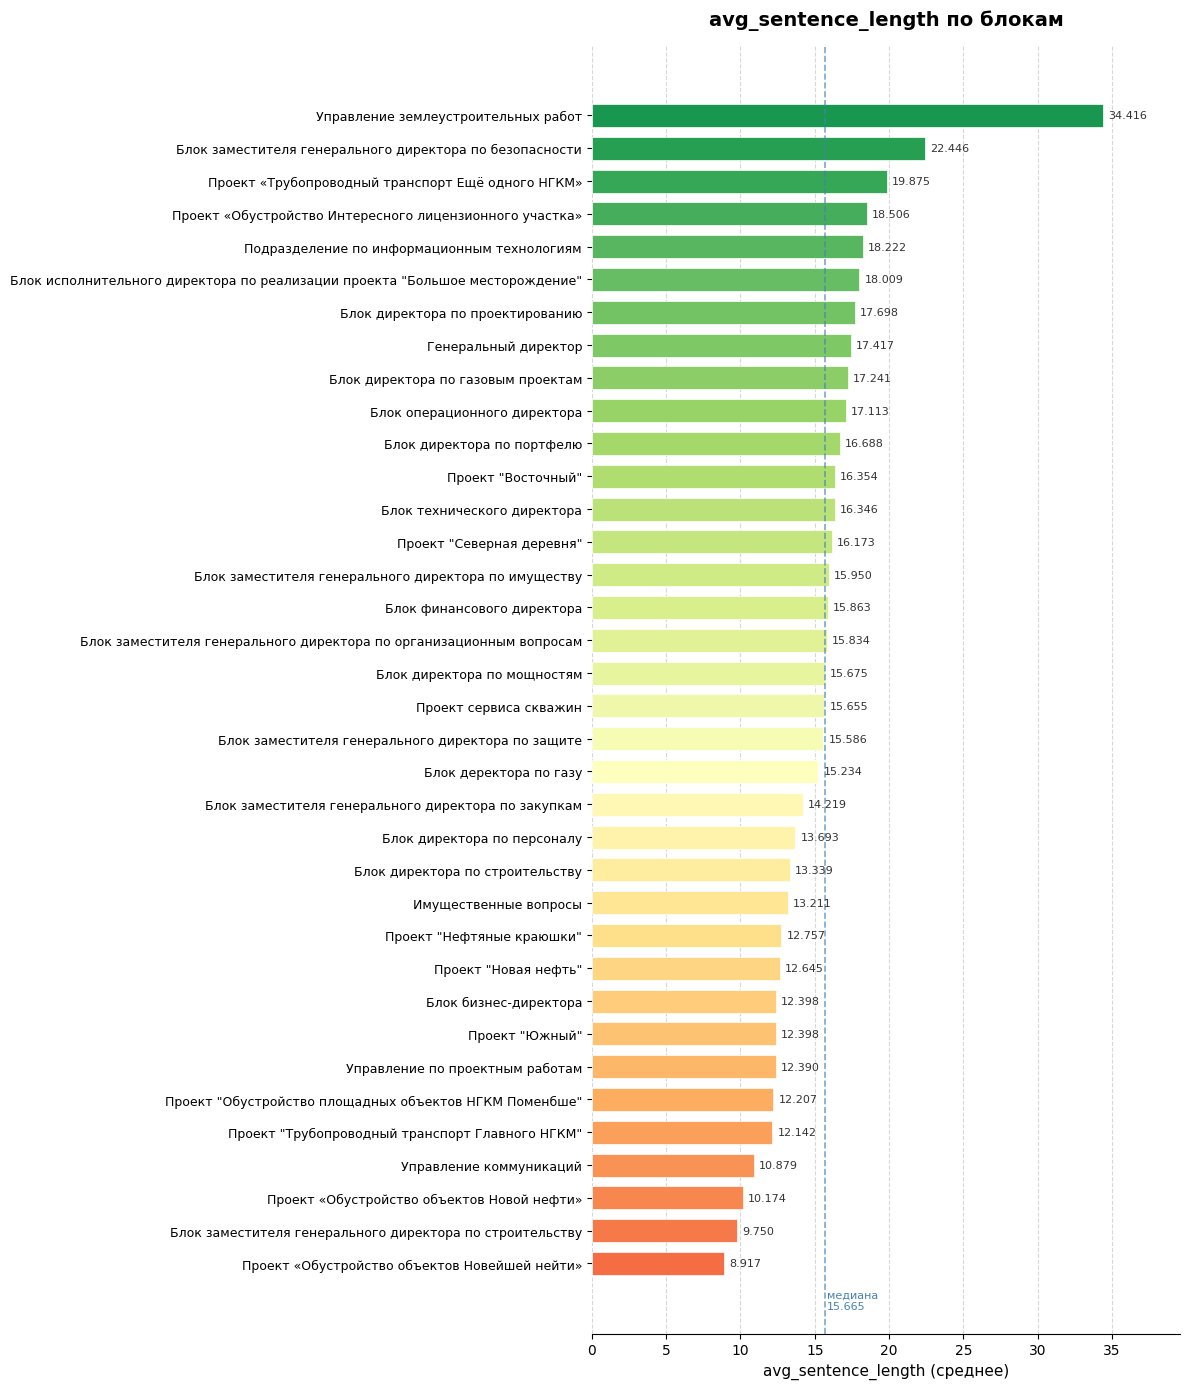

In [44]:
plot_metric_by_label(data, 'avg_sentence_length')

Ниже медианы расположены в основном операционные блоки, где требуется скорость и точность указаний и меньше терминогогии и бюрократизма.

Так же видим аномольно длинные предложения в блоке управление землеустроительных работ. 
По количеству уникальных слов этот блок так же впереди всех остальных.

Выделим письмо с самыми длинными предложениями в этом блоке и проверим его на аномалию.

In [45]:
data[data['label'] == 'Управление землеустроительных работ'].sort_values('avg_sentence_length', ascending=False).head(1)['text'].values[0]

'[ORGANIZATION] Саха Ореспууьылукэтин Экологияа, айылбаны тунасыга уонна ойыр ханаайыстыбатыгар министиэристибэтэ [ORGANIZATION] ГОСУДАРСТВЕННОЕ КАЗЕННОЕ УЧРЕЖДЕНИЕ РЕСПУБЛИКИ САХА (ЯКУТИЯ) [OBJECT] 678170, [LOCATION] Тел: [CONTACT]; [CONTACT] e-mail: [CONTACT] [DATE_TIME] No[DOCUMENT_NUMBER] [ORGANIZATION] Федорову [PERSON] Между [ORGANIZATION] и [ORGANIZATION] заключены договора аренды лесных участков: * [DOCUMENT_NUMBER] от [DATE_TIME] на общей площади [FINANCIAL_DATA] га под дорогу автомобильную; * [DOCUMENT_NUMBER] от [DATE_TIME] на общей площади [FINANCИAL_DATA] га под дорогу автомобильную; * [DOCUMENT_NUMBER] от [DATE_TIME] на общей площади [FINANCIAL_DATA] га под Площадку производственную с покрытием, дорога автомобильная, линия электропередачи воздушная, кабельная всех классов напряжения, трубопровод подземный; * [DOCUMENT_NUMBER] от [DATE_TIME] на общей площади [FINANCIAL_DATA] га под Площадку производственную с покрытием; * [DOCUMENT_NUMBER] от [DATE_TIME] на общей площади [

Видим, что данное письмо содержит огромный перечень, который распарсился как одно предложение, в этом и есть причина аномально длинных предложений в данном блоке.

___
Доля длинных слов в тексте

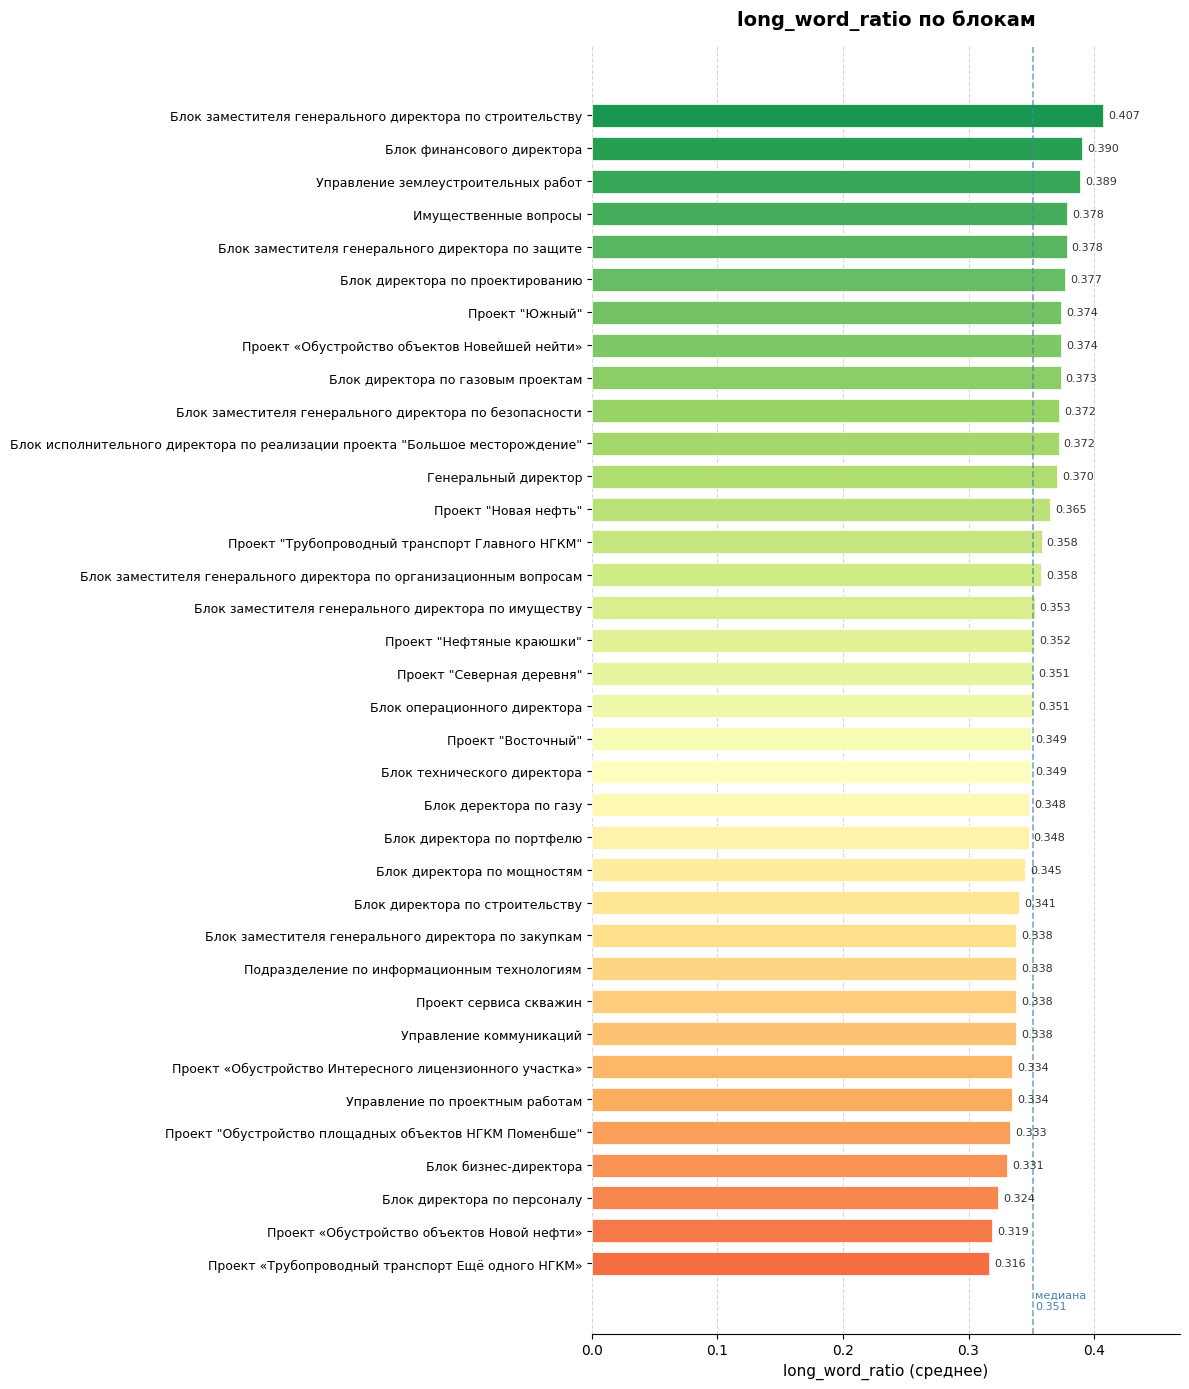

In [46]:
plot_metric_by_label(data, 'long_word_ratio')

По данному признаку разброс очень слабый, по этому он  был бы мало чем полезен при классификации
___

Hapax - доля уникальных слов.

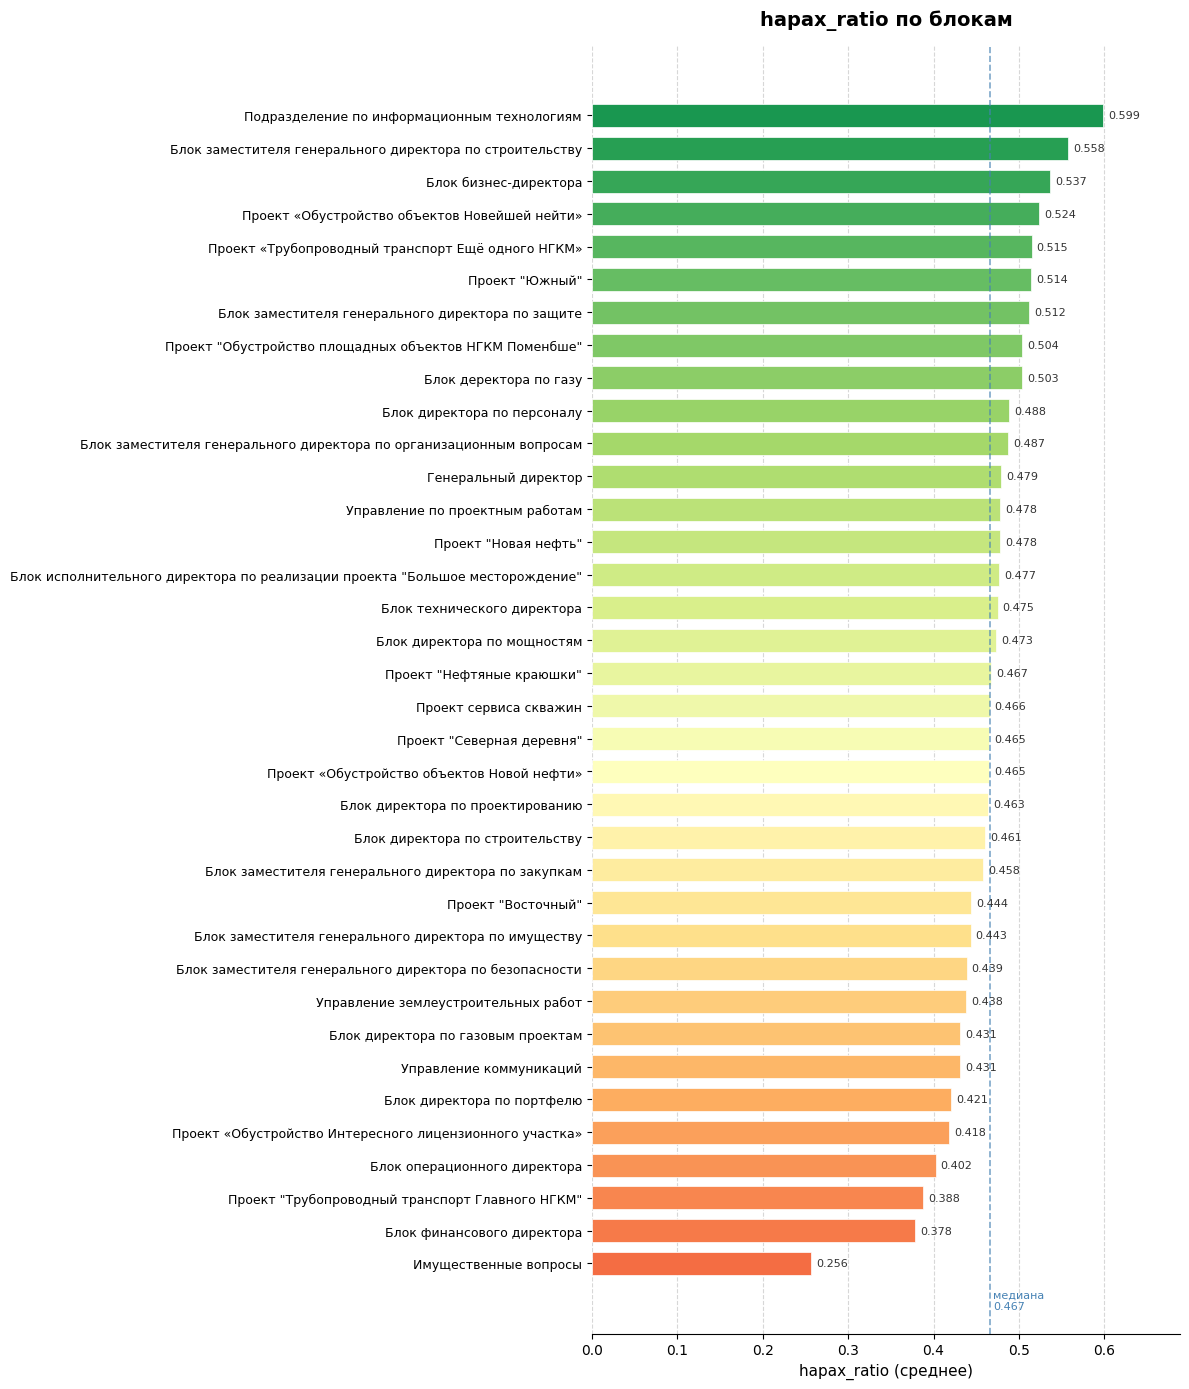

In [47]:
plot_metric_by_label(data, 'hapax_ratio')  

Проект «Трубопроводный транспорт Ещё одного НГКМ» — на long_word_ratio был последним (0.316), а на hapax_ratio высоко (0.515).

Короткие слова, но каждое уникально что может указывать на разнообразие тем в переписке по проекту.

Подразделение по информационным технологиям лидирует с большим отрывом, но из за того что в качестве примеров имеет всего два коротких письма, сложно обобощить о нем информацию по данному паттерну.

Блоки внизу графика — шаблонная документация, блоки вверху — живая уникальная переписка.
___

Оценим блоки в совокупности.

In [48]:

data.groupby('label')[['ttr', 'rttr', 'avg_sentence_length', 'word_count',
                     'long_word_ratio', 'hapax_ratio']].mean().sort_values('rttr', ascending=False)

,ttr,rttr,avg_sentence_length,word_count,long_word_ratio,hapax_ratio
label,,,,,,
Имущественные вопросы,0.405437,11.199361,13.210986,846.000000,0.378444,0.256494
Проект «Трубопроводный транспорт Ещё одного НГКМ»,0.661755,10.225052,19.875000,238.500000,0.316168,0.514788
Подразделение по информационным технологиям,0.728158,10.093220,18.222222,192.000000,0.337830,0.598683
"Блок исполнительного директора по реализации проекта ""Большое месторождение""",0.615299,9.544733,18.009337,239.600000,0.371723,0.476793
"Проект ""Северная деревня""",0.627960,8.800412,16.173329,228.833333,0.351183,0.465456
Блок заместителя генерального директора по защите,0.657543,8.723177,15.586173,204.923077,0.378132,0.512066
Блок заместителя генерального директора по безопасности,0.599535,8.717909,22.446383,282.796748,0.371846,0.438660
Блок технического директора,0.629254,8.614234,16.346345,236.995935,0.349413,0.475010
Блок бизнес-директора,0.695572,8.532973,12.398399,155.500000,0.330975,0.536867


**Выводы:**

Имеется группа блоков содержащих длинные шаблонные документы(низкий ttr и высокое количество слов):
- Имущественные вопросы                             
- Проект «Обустройство Интересного лицензионного»  
- Проект «Трубопроводный транспорт Главного НГКМ»   
- Управление землеустроительных работ             
- Проект «Обустройство объектов Новой нефти»

Есть напротив группа с высоким ttr и малым количеством слов - уникальная адресная переписка:
- Подразделение по информационным технологиям   
- Блок бизнес-директора                         
- Проект «Обустройство объектов Новейшей нейти» 
- Блок заместителя ГД по строительству          

но они содержат мало примеров

Данные блоки выделяются аномально короткими предложениями. Что может помочь отличить их от остальных:
- Блок директора по проектированию — sentence_count=41 при среднем word_count=314.
- Проект «Обустройство объектов Новой нефти» — sentence_count=66 при среднем word_count=525.


Большинство блоков, а именно 25, по рассмотренным харрактеристикам практически не отличимы и находятся в средних значениях:
- *word_count:          150-350*
- *ttr:                 0.58-0.65*
- *hapax_ratio:         0.44-0.50*
- *long_word_ratio:     0.33-0.38*
- *avg_sentence_length: 12-22*

Попробуем найти отличия семантическими методами.


___

### Класстеризация по смысловому наполнению.
Подготовим данные извлечем тексты из датафрема и преобразуем их в эмбеддинги.

Для эмбеддингов выбрана модель paraphrase-multilingual-MiniLM-L12-v2. Она относится к семейству Sentense-Bert. Легкая и работает с русским языком.

In [49]:
texts = data["text"].astype(str).tolist()
device = "cpu"
#  Эмбеддинги 
print("Encoding...")
model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2", device=device)
embeddings = model.encode(texts, batch_size=64, show_progress_bar=True)

Encoding...


Batches:   0%|          | 0/28 [00:00<?, ?it/s]

Снижаем размерность векторных представлений до 2D плоскости

In [50]:
print("UMAP...")
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=40,      
    min_dist=0.1, # для плотности и компактности кластеров
    metric="cosine",
    random_state=42
)
embedding_2d = reducer.fit_transform(embeddings)

UMAP...


Кластеризуем тексты в 2D пространстве с помощью HDBSCAN

In [51]:
print("Clustering...")
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=15,   # 1% от датасета 
    min_samples=5,
    metric="euclidean"     # кластеризуем в 2D пространстве
)
cluster_labels = clusterer.fit_predict(embedding_2d)

Clustering...


Визуализируем.

In [52]:
labels = data["label"].astype(str).tolist()
# данные для визуализации
df_plot = pd.DataFrame({
    "x":           embedding_2d[:, 0],
    "y":           embedding_2d[:, 1],
    "label":       labels,
    "cluster":     cluster_labels.astype(str),
    "text_preview": [t[:120] + "..." for t in texts]
})

fig = px.scatter(
    df_plot,
    x="x", y="y",
    color="label",
    hover_data=["text_preview", "cluster", "label"],
    title="UMAP — семантическое пространство писем (цвет = разметка)",
    color_discrete_sequence=px.colors.qualitative.Alphabet,  # 26 цветов
    width=1200, height=800,
    opacity=0.8
)
fig.update_traces(marker=dict(size=7))
fig.update_layout(legend=dict(
    font=dict(size=9),
    itemsizing="constant",
    title="Класс"
))
fig.write_html("umap_emails.html")
fig.show()
print("Готово → umap_emails.html")

# ── 7. Метрики совпадения кластеров с разметкой ───────────────────────────────
print( f"Найдено кластеров   : {len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)}")
print(f"Шумовых точек       : {(cluster_labels == -1).sum()} / {len(cluster_labels)}")

Готово → umap_emails.html
Найдено кластеров   : 7
Шумовых точек       : 11 / 1755


In [53]:
# Посмотрим как разметка распределилась по кластерам
print("\nРаспределение классов по кластерам:")
crosstab = pd.crosstab(df_plot['label'], df_plot['cluster'])
crosstab


Распределение классов по кластерам:


cluster,-1,0,1,2,3,4,5,6
label,,,,,,,,
Блок бизнес-директора,0,0,0,0,8,0,0,0
Блок деректора по газу,2,0,0,0,68,0,0,1
Блок директора по газовым проектам,0,1,0,4,26,0,0,0
Блок директора по мощностям,1,0,0,14,210,0,0,16
Блок директора по персоналу,0,0,0,9,9,0,0,0
Блок директора по портфелю,0,0,0,1,23,0,0,0
Блок директора по проектированию,0,0,0,4,39,0,0,0
Блок директора по строительству,2,23,7,7,91,2,15,18
Блок заместителя генерального директора по безопасности,0,0,0,12,110,1,0,0


Найдем по кластерам часто встречающиеся фразы с помощью TF-IDF.

In [54]:
# Добавляем cluster_labels в основной датафрейм
data_clustered = data.iloc[:len(cluster_labels)].copy()
data_clustered['cluster'] = cluster_labels


#  Исключаем шум
data_no_noise = data_clustered[data_clustered['cluster'] != -1]

# TF-IDF по кластерам
group_texts = data_no_noise.groupby('cluster')['text'].apply(lambda x: ' '.join(x))

vectorizer = TfidfVectorizer(
    max_features=10000,
    min_df=2,
    ngram_range=(1, 2),
    sublinear_tf=True
)
tfidf_matrix = vectorizer.fit_transform(group_texts)
feature_names = vectorizer.get_feature_names_out()

# Топ-слова + какие классы разметки преобладают в кластере
print("=" * 150)
for i, cluster_id in enumerate(group_texts.index):
    # Топ слова
    row = tfidf_matrix[i].toarray()[0]
    top_idx = row.argsort()[::-1][:8]
    top_words = [feature_names[j] for j in top_idx if row[j] > 0]
    
    # Преобладающие классы разметки
    cluster_data = data_no_noise[data_no_noise['cluster'] == cluster_id]
    top_labels = cluster_data['label'].value_counts().head(3)
    n_total = len(cluster_data)
    
    print(f"\n {'=' * 40} Кластер {cluster_id} ({n_total} писем){'=' * 40}")
    print(f"   Топ слова : {' | '.join(top_words)}")
    print(f"   Топ классы:")
    for lbl, cnt in top_labels.items():
        pct = cnt / n_total * 100
        print(f"     {cnt:3d} ({pct:4.1f}%)  {lbl}")
print("=" * 150)


 ======================================== Кластер 0 (37 писем)========================================
   Топ слова : position group | group до | description financial_data | 1000в | product product | до выше | выше 1000в | гр
   Топ классы:
      23 (62.2%)  Блок директора по строительству
       7 (18.9%)  Блок технического директора
       4 (10.8%)  Проект «Обустройство Интересного лицензионного участка»

 ======================================== Кластер 1 (27 писем)========================================
   Топ слова : местонахождения | description | обособленного | обособленного подразделения | да | no2 location | стр | person position
   Топ классы:
      10 (37.0%)  Проект "Трубопроводный транспорт Главного НГКМ"
       7 (25.9%)  Проект «Обустройство объектов Новой нефти»
       7 (25.9%)  Блок директора по строительству

 ======================================== Кластер 2 (105 писем)========================================
   Топ слова : опасного производственного | опасног

У нас выделилось 7 кластеров, большая часть писем сливается в кластере 3.

Разобьем кластеры на темы изходя из ключевых выделенных слов.

- Кластер 0:  Письма с финансовыми показателями, структурой должностей, данными по продуктам
- Кластер 1:  Данные о местоположении, адресах
- Кластер 2:  Производственная безопасность
- Кластер 3:  Размытый класс с общей тематикой.
- Кластер 4:  Данные, номера (возможно документов)
- Кластер 5:  Реквизиты писем
- Кластер 6:  Финансовые данные по филлиалам

___
### Тематическое моделирование LDA 
Для сравнения попробуем метод тематического моделирования -  Latent Dirichlet Allocation (LDA).

Текст разбивается на массив слов, удаляются стоп-слова, остальные слова приводятся к начальной форме(лемматизируются)

In [48]:
# загрузка модели
nlp = spacy.load("en_core_web_sm", enable=["lemmatizer"])

processed_texts = []

for text in data['text'].astype(str).tolist():
    doc = nlp(text)
    
    # лемматизация + удаление стоп-слов и пунктуации
    lemmas = [
        token.lemma_.lower() 
        for token in doc 
        if not token.is_stop 
        and not token.is_punct 
        and token.is_alpha
    ]
    
    processed_texts.append(lemmas)

Получим векторное представление с помощью техники унитарного кодирования, называемой "Мешок слов"(BOW). Он превращает фразы или целые предложения в бинарные векторы.

In [49]:
# создаём словарь
dic = corpora.Dictionary(processed_texts)

# создаём корпус в формате BOW
bow_corpus = [dic.doc2bow(text) for text in processed_texts]

Запустим модель LDA

In [50]:
# задаём количество тем 
num_topics = 30

lda_model = LdaMulticore(
    bow_corpus,
    num_topics=num_topics,
    id2word=dic,
    passes=10,
    workers=2,
    batch=True
)

Визуализируем

In [51]:
pyLDAvis.enable_notebook()

vis = gensim_lda.prepare(lda_model, bow_corpus, dic)
vis

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
18     0.213352  0.057074       1        1  32.250929
29     0.210417  0.047696       2        1  14.956644
25     0.129299 -0.082114       3        1  11.327042
10     0.161133  0.021411       4        1   5.605953
19     0.164396 -0.216764       5        1   4.985804
6      0.157122 -0.012472       6        1   4.852345
9      0.186005  0.004242       7        1   3.623762
20     0.146792 -0.043459       8        1   3.502081
27     0.153820 -0.008998       9        1   3.416450
5      0.172319  0.138036      10        1   2.866333
13     0.167603  0.104972      11        1   2.714684
24     0.070881 -0.120683      12        1   1.646880
1      0.068846 -0.035894      13        1   1.346643
4      0.050753  0.048273      14        1   1.059387
21     0.016374  0.078745      15        1   0.917036
14     0.040211 -0.000427      16        1   0.807566
3      0.000549  0.034674      17        1   0.774172
15    -0.008060 -0.069247      18        1   0.753160
22     0.019600 -0.012764      19        1   0.737469
12    -0.071726  0.031422      20        1   0.637030
8     -0.127243  0.034775      21        1   0.333807
17    -0.168209  0.029085      22        1   0.274539
16    -0.185526  0.011046      23        1   0.154657
11    -0.226722 -0.011738      24        1   0.118015
2     -0.224927  0.005703      25        1   0.109178
23    -0.188024 -0.004454      26        1   0.102106
7     -0.232922 -0.010713      27        1   0.039165
26    -0.228424 -0.006799      28        1   0.037326
28    -0.237258 -0.003965      29        1   0.030875
0     -0.230431 -0.006660      30        1   0.018961, topic_info=              Term          Freq         Total Category  logprob  loglift
2           person   8442.000000   8442.000000  Default  30.0000  30.0000
5                в   9276.000000   9276.000000  Default  29.0000  29.0000
1     organization  10103.000000  10103.000000  Default  28.0000  28.0000
28              на   8033.000000   8033.000000  Default  27.0000  27.0000
23               и   7038.000000   7038.000000  Default  26.0000  26.0000
...            ...           ...           ...      ...      ...      ...
1072            из      0.003649    353.187144  Topic30  -9.6749  -2.9097
128     приложение      0.003863   1192.527662  Topic30  -9.6181  -4.0696
1141      объектов      0.003654    545.030134  Topic30  -9.6736  -3.3422
510              п      0.003556    293.706511  Topic30  -9.7009  -2.7512
55           также      0.003580    606.696512  Topic30  -9.6942  -3.4699

[2088 rows x 6 columns], token_table=       Topic      Freq            Term
term                                  
7080      25  0.754306      additional
2369       2  0.059899  administration
2369       3  0.119797  administration
2369       4  0.179696  administration
2369      16  0.598985  administration
...      ...       ...             ...
546        6  0.107347           ямало
546       11  0.053674           ямало
546       22  0.429389           ямало
19999     22  0.856825       ямальских
14104      3  0.966445            янао

[5636 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[19, 30, 26, 11, 20, 7, 10, 21, 28, 6, 14, 25, 2, 5, 22, 15, 4, 16, 23, 13, 9, 18, 17, 12, 3, 24, 8, 27, 29, 1])

Видим так же как и по итогам кластеризации, что большинство писем находятся в близких секторах и тематически  близки, за исключением некоторых небольших групп.